In [1]:
!pip install tensorflow
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install pillow
!pip install opencv-python
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 106.0 MB/s eta 0:00:00


In [2]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
# Load dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Print dataset shapes

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


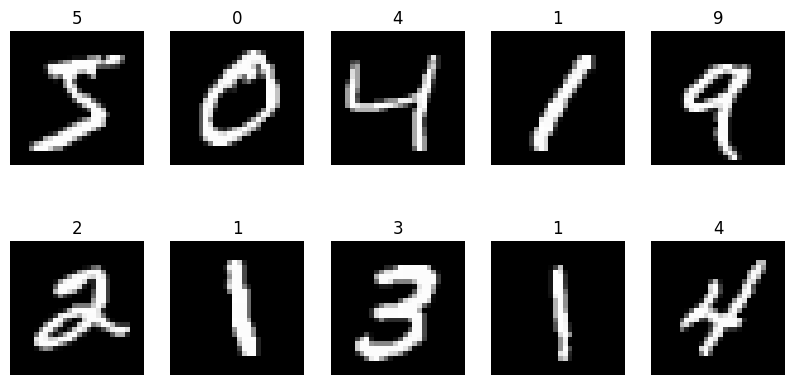

In [4]:
# Display first 10 images

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title(y_train[i])

    plt.axis('off')

plt.show()

In [5]:
# Reshape images

X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)

# Normalize pixel values

X_train = X_train / 255.0
X_test = X_test / 255.0

# Convert labels into categorical format

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("Preprocessing Completed")

Preprocessing Completed


In [6]:
# Create CNN model

model = Sequential()

# First Convolution Layer

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

# First Pooling Layer

model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Second Convolution Layer

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Second Pooling Layer

model.add(
    MaxPooling2D(pool_size=(2,2))
)

# Flatten Layer

model.add(Flatten())

# Dense Layer

model.add(
    Dense(
        128,
        activation='relu'
    )
)

# Dropout Regularization

model.add(
    Dropout(0.5)
)

# Output Layer

model.add(
    Dense(
        10,
        activation='softmax'
    )
)

# Display model summary

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [8]:
# Train model

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step - accuracy: 0.9137 - loss: 0.2790 - val_accuracy: 0.9792 - val_loss: 0.0730
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 55ms/step - accuracy: 0.9719 - loss: 0.0951 - val_accuracy: 0.9876 - val_loss: 0.0441
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9805 - loss: 0.0670 - val_accuracy: 0.9873 - val_loss: 0.0436
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9834 - loss: 0.0537 - val_accuracy: 0.9893 - val_loss: 0.0365
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9861 - loss: 0.0445 - val_accuracy: 0.9905 - val_loss: 0.0329


In [9]:
# Evaluate model

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9904 - loss: 0.0275
Test Loss: 0.027498317882418633
Test Accuracy: 0.9904000163078308


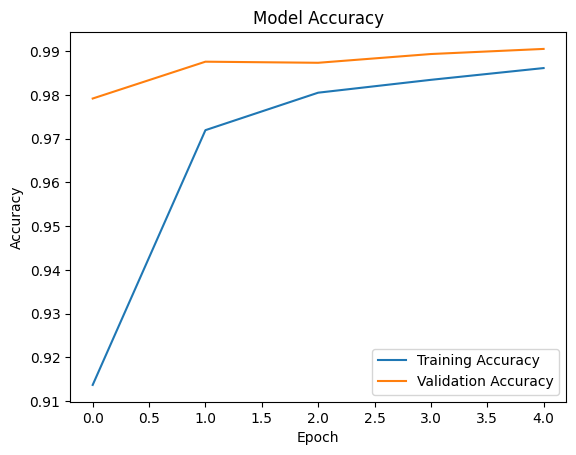

In [10]:
# Plot accuracy graph

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

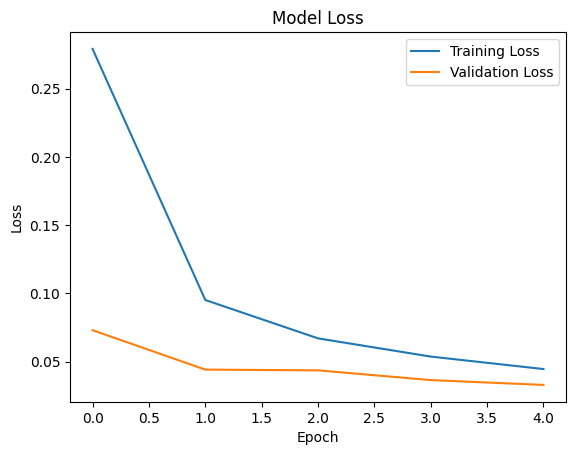

In [11]:
# Plot loss graph

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

In [12]:
# Predict test images

y_pred = model.predict(X_test)

# Convert predictions

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


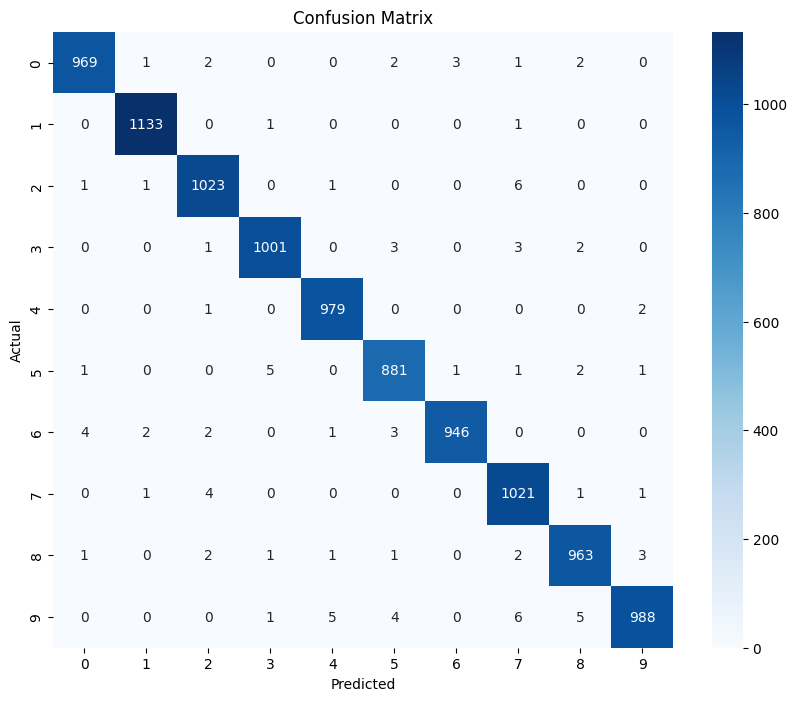

In [13]:
# Generate confusion matrix

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

# Display confusion matrix

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [14]:
# Print classification report

print(
    classification_report(
        y_true,
        y_pred_classes
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [15]:
# Save trained model

model.save("digit_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [24]:
# INSTALL REQUIRED LIBRARIES

!pip uninstall numpy -y
!pip install numpy==1.26.4
!pip install tensorflow
!pip install streamlit
!pip install pyngrok
!pip install pillow

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 req

In [25]:
# IMPORT LIBRARIES

import numpy as np

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

In [26]:
# LOAD DATASET

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)

print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [27]:
# PREPROCESS DATA

X_train = X_train.reshape(60000,28,28,1)

X_test = X_test.reshape(10000,28,28,1)

X_train = X_train / 255.0

X_test = X_test / 255.0

y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [28]:
# BUILD CNN MODEL

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)

model.add(Flatten())

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(
        10,
        activation='softmax'
    )
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# COMPILE MODEL

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
# TRAIN MODEL

model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - accuracy: 0.9170 - loss: 0.2682 - val_accuracy: 0.9798 - val_loss: 0.0703
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9702 - loss: 0.0966 - val_accuracy: 0.9856 - val_loss: 0.0495
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 90s 68ms/step - accuracy: 0.9785 - loss: 0.0714 - val_accuracy: 0.9876 - val_loss: 0.0426
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 76s 59ms/step - accuracy: 0.9833 - loss: 0.0560 - val_accuracy: 0.9885 - val_loss: 0.0405
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.9860 - loss: 0.0455 - val_accuracy: 0.9893 - val_loss: 0.0404


In [35]:
# SAVE MODEL

model.save("digit_model.h5")

print("MODEL SAVED")

MODEL SAVED


In [36]:
# CREATE STREAMLIT APP FILE

%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# LOAD MODEL

model = tf.keras.models.load_model(
    "digit_model.h5"
)

# TITLE

st.title(
    "Handwritten Digit Recognition"
)

st.write(
    "Upload a digit image"
)

# FILE UPLOAD

uploaded_file = st.file_uploader(
    "Choose Image",
    type=["png","jpg","jpeg"]
)

if uploaded_file is not None:

    # OPEN IMAGE

    image = Image.open(
        uploaded_file
    ).convert('L')

    # SHOW IMAGE

    st.image(
        image,
        caption="Uploaded Image",
        width=150
    )

    # RESIZE IMAGE

    image = image.resize((28,28))

    # IMAGE TO ARRAY

    img = np.array(image)

    # INVERT COLORS

    img = 255 - img

    # NORMALIZE

    img = img / 255.0

    # RESHAPE

    img = img.reshape(1,28,28,1)

    # PREDICT

    prediction = model.predict(img)

    predicted_digit = np.argmax(prediction)

    # SHOW RESULT

    st.success(
        f"Predicted Digit: {predicted_digit}"
    )

Overwriting app.py


In [37]:
# RUN STREAMLIT

from pyngrok import ngrok

In [38]:
# START STREAMLIT

!streamlit run app.py &>/dev/null&

In [39]:
# CREATE PUBLIC LINK

public_url = ngrok.connect(8501)

public_url

ERROR:pyngrok.process.ngrok:t=2026-05-25T17:01:55+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-05-25T17:01:55+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-05-25T17:01:55+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

Handwritten Digit Recognition
Upload a digit image


Saving image handwriten.webp to image handwriten.webp


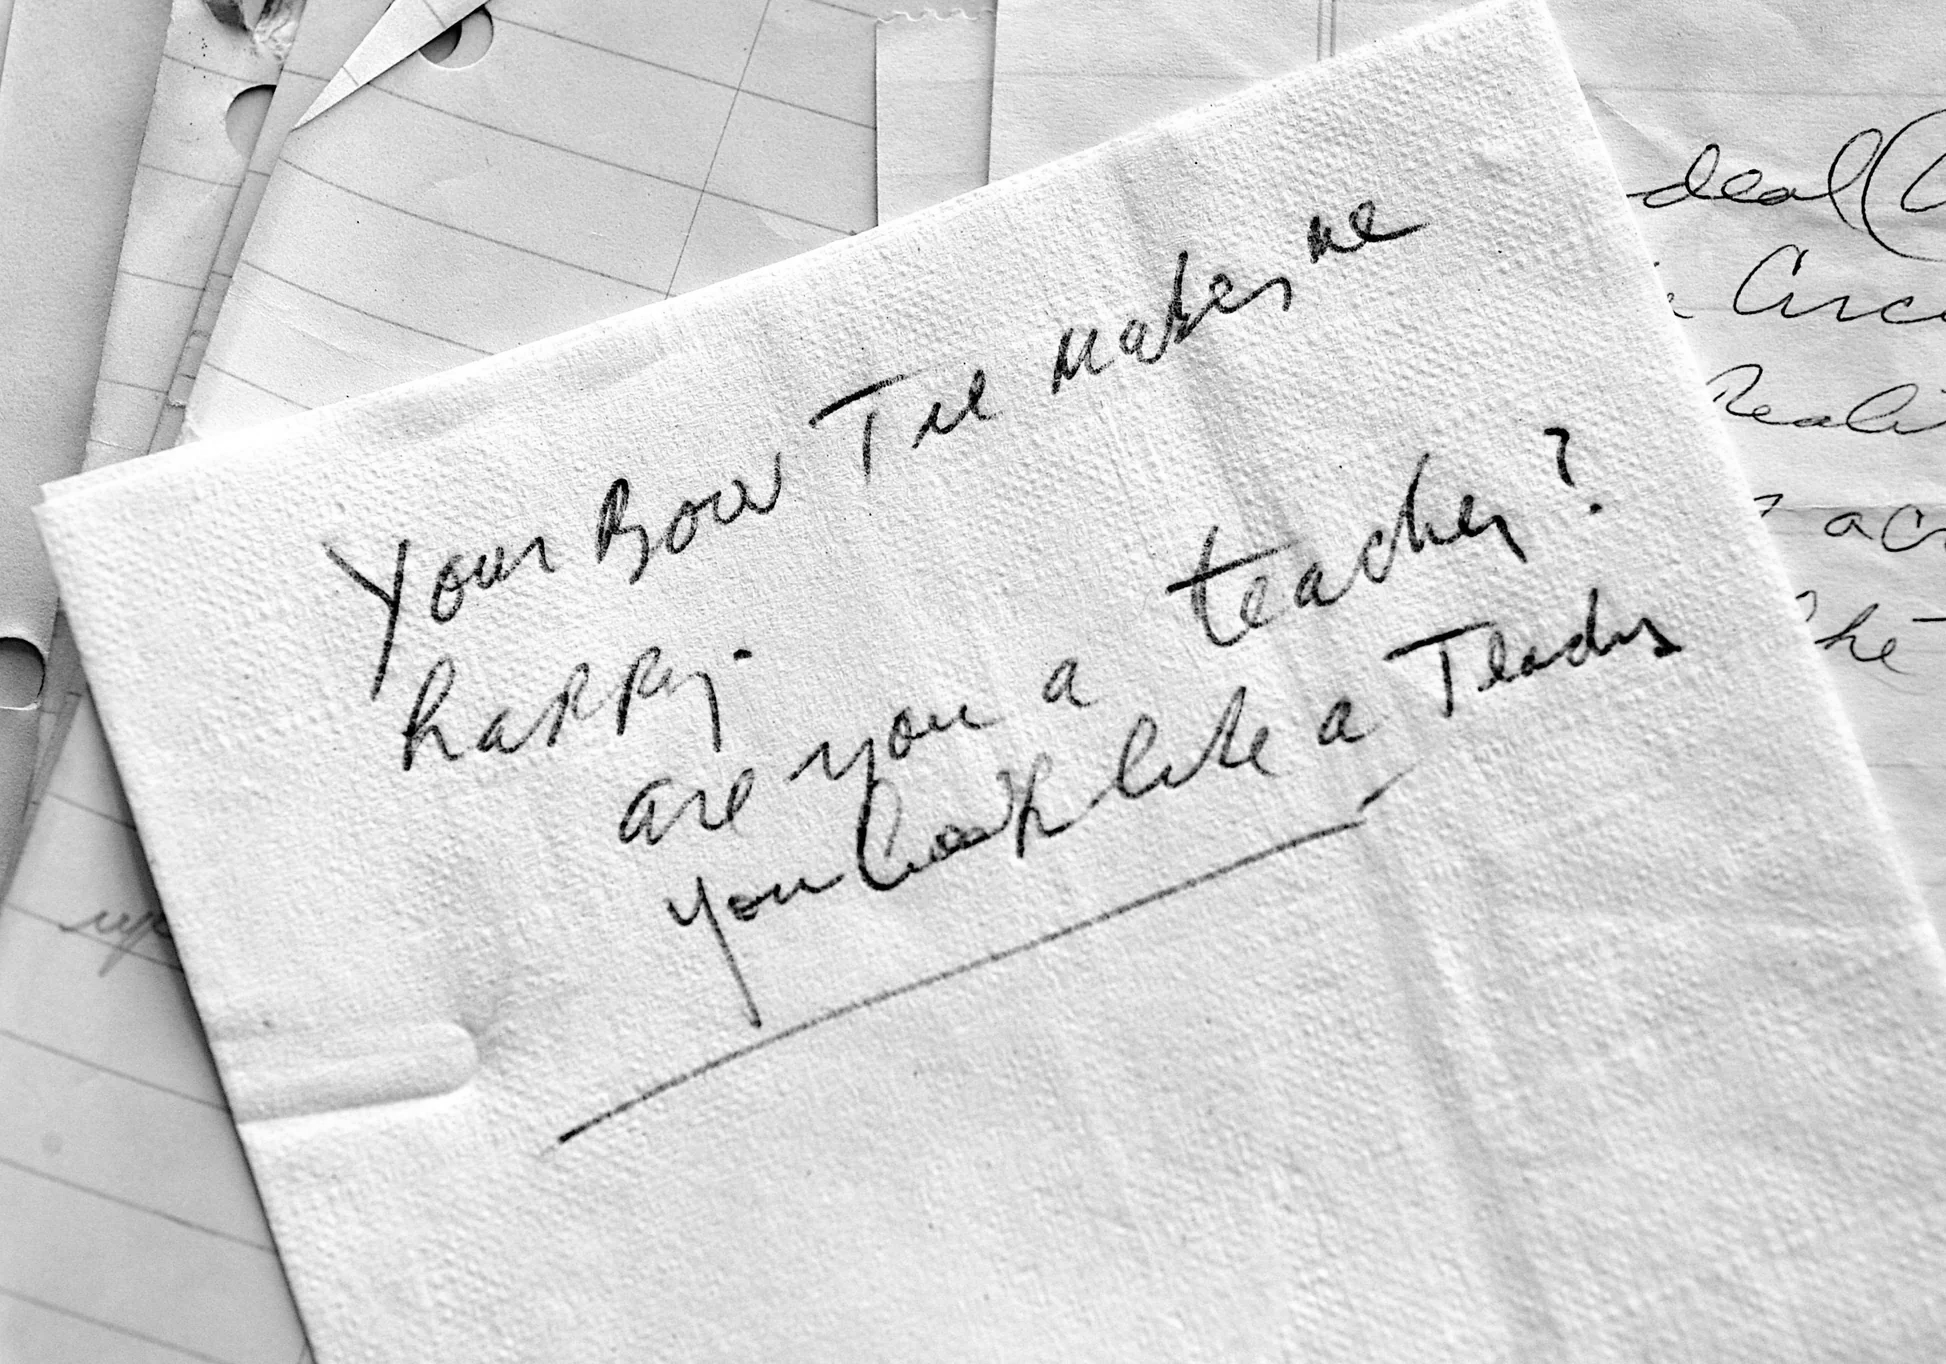

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
Predicted Digit is: 3


In [40]:
# RUN THIS CELL IN GOOGLE COLAB

import ipywidgets as widgets
from IPython.display import display
from PIL import Image
import numpy as np
import tensorflow as tf
from google.colab import files
import io

# LOAD MODEL

model = tf.keras.models.load_model("digit_model.h5")

# TITLE

print("Handwritten Digit Recognition")

print("Upload a digit image")

# UPLOAD BUTTON

uploaded = files.upload()

# PROCESS IMAGE

for filename in uploaded.keys():

    image = Image.open(
        io.BytesIO(uploaded[filename])
    ).convert('L')

    # DISPLAY IMAGE

    display(image)

    # RESIZE IMAGE

    image = image.resize((28,28))

    # CONVERT TO ARRAY

    img = np.array(image)

    # INVERT COLORS

    img = 255 - img

    # NORMALIZE

    img = img / 255.0

    # RESHAPE

    img = img.reshape(1,28,28,1)

    # PREDICT

    prediction = model.predict(img)

    predicted_digit = np.argmax(prediction)

    # RESULT

    print("Predicted Digit is:", predicted_digit)